In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gapMetrics
import bacteriaSys
import controllers
import csv
import time
random.seed(1)  # For reproducibility
np.random.seed(1)

In [2]:
#Function from data to bpc
# Assumed P controller with gain K
def data_to_bpc(u,x,K):
    A_hat, B_hat = gapMetrics.estimate_AB(u.T, x.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num, den = gapMetrics.ss_to_tf_discrete(A_hat, B_hat, C, D)
    Abk = A_hat - B_hat * K
    num3, den3 = gapMetrics.ss_to_tf_discrete(Abk, B_hat, C, D)
    bpc, _, _ = gapMetrics.vgap_bpc(num, den, num3, den3)
    return bpc

#
def data_to_vgap(u1, x1, u2, x2):
    A_hat1, B_hat1 = gapMetrics.estimate_AB(u1.T, x1.T)
    A_hat2, B_hat2 = gapMetrics.estimate_AB(u2.T, x2.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num1, den1 = gapMetrics.ss_to_tf_discrete(A_hat1, B_hat1, C, D)
    num2, den2 = gapMetrics.ss_to_tf_discrete(A_hat2, B_hat2, C, D)
    v_gap, _ = gapMetrics.vgap_metric(num1, den1, num2, den2)
    return v_gap

def direct_vgap(A1, B1, C1, D1, A2, B2, C2, D2):
    num1, den1 = gapMetrics.ss_to_tf_discrete(A1, B1, C1, D1)
    num2, den2 = gapMetrics.ss_to_tf_discrete(A2, B2, C2, D2)
    v_gap, _ = gapMetrics.vgap_metric(num1, den1, num2, den2)
    return v_gap

In [3]:
#LQR wrapper

def LQR_wrapper(u,x):
    Q = np.eye(2)
    # Q[0, 0] = 0
    R = np.eye(1)*0.1 #TODO: can adapt to n change
    T_d = 20  #data length for LQR
    U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
    X0 = x[0:T_d, :].T # shape (n, T)  == X_{0,T}
    X1 = x[1:T_d+1, :].T # shape (n, T)  == X_{1,T}
    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
    return K_control

#for testing SISO
# Q = np.eye(2)*10
#     Q[0, 0] = 0
#     R = np.eye(1)*0.01

In [4]:
def generate_random_system(A0, B0, sigma_max):
    """
    Generate one random system (A, B, C, D) by perturbing a nominal system.

    Parameters
    ----------
    A0, B0 : np.ndarray
        Nominal system matrices
    sigma_max : float
        Maximum standard deviation for perturbation

    Returns
    -------
    A, B, C, D : np.ndarray
        Perturbed system matrices
    sigma : float
        Sampled noise level for this system
    """
    import numpy as np

    # Sample system-specific noise level
    sigma = np.random.uniform(0.0, sigma_max)

    # Generate Gaussian perturbations
    dA = np.random.normal(0.0, sigma, size=A0.shape)
    dB = np.random.normal(0.0, sigma, size=B0.shape)

    # Construct system
    A = A0 + dA
    B = B0 + dB
    C = np.eye(A.shape[0])  # Identity output matrix
    D = np.zeros((C.shape[0], B.shape[1]))

    # # Ensure stability (optional but recommended)
    # eigvals = np.linalg.eigvals(A)
    # rho = max(abs(eigvals))
    # if rho >= 0.99:
    #     A = A / rho * 0.95

    return A, B, C, D

In [11]:
#define parameters
num_systems = 50
T = 50 #number of data points each system
L = 15  #Hankel matrix depth; 15 before
p = 2 #output dimension
# p = 1 #output dimension
n = 2   # state dimension
m = 1 #input dimension
# C = np.array([[0, 1]])
C = np.eye(p)
D = np.zeros((p, m))
u = gapMetrics.persistently_exciting_input(T, m=1, std=1.0)
H_u = gapMetrics.hankel_matrix(u, L)
#Check rank of H_u
rank_H_u = np.linalg.matrix_rank(H_u)
if rank_H_u < L:
    print(f"Warning: Hankel matrix of input has rank {rank_H_u} which is less than L={L}.")
else:
    print(f"Hankel matrix of input has full rank {rank_H_u}.")

Hankel matrix of input has full rank 15.


In [12]:
#Do not run when reusing the 100 fixed output
C = np.eye(p) #*0.7
stored_x = []
stored_y = []
#store A and B for checking
stored_A = []
stored_B = []
stored_hankels = []
random.seed(1) #for reproducibility
for i in range(num_systems):
    A, B, C, D = gapMetrics.random_discrete_system_stable(n=2, m=1, p=1)
    # A, B, _, _ = generate_random_system(np.array([[0.8, 0.1], [0.0, 0.9]]), np.array([[0.1], [0.05]]), sigma_max=0.02)
    # A, B, _, _ = random_discrete_system_stable(n=2, m=1, p=1, rho_target=0.5)
    # print("A matrix:\n", A)
    # print("B matrix:\n", B)
    x, y = gapMetrics.simulate_system(A, B, C, D, u)
    # print("y shape:", y.shape)
    H_y = gapMetrics.hankel_matrix(y, L)
    # print("H_y shape:", H_y.shape)
    H = np.vstack([H_u, H_y])
    stored_x.append(x)
    stored_y.append(y)
    stored_hankels.append(H)
    stored_A.append(A)
    stored_B.append(B)

In [7]:
#Do not run if you are generating new random systems, only if you are reusing the fixed output
data = np.load("systems_data3.npz", allow_pickle=True)

stored_x = data["stored_x"]
stored_y = data["stored_y"]
stored_hankels = data["stored_hankels"]
stored_A = data["stored_A"]
stored_B = data["stored_B"]
u = data["u"]


In [ ]:
#Do not run
#Backup data 3 for 50 random systems, for testing
#
np.savez(
    "systems_data3.npz",
    stored_x=stored_x,
    stored_y=stored_y,
    stored_hankels=stored_hankels,
    stored_A=stored_A,
    stored_B=stored_B,
    u=u
)
#3 and 20 cannot share the same controller

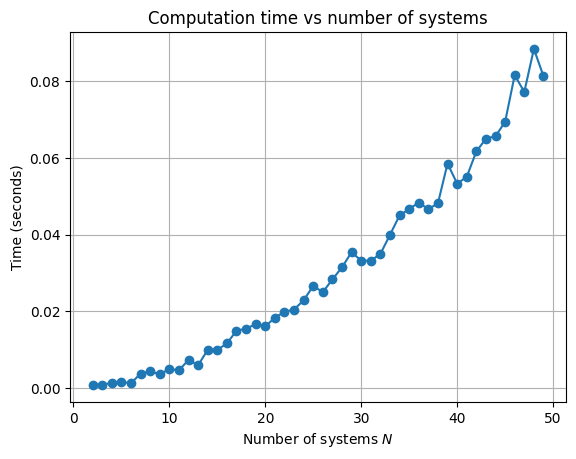

In [16]:
#runtime check
N_vals = np.arange(2, 50)  # avoid N=0,1
times = []

num_runs = 10  # average over runs

for N_temp in N_vals:
    stored_hankels_temp = stored_hankels[:N_temp]
    
    t_total = 0
    for _ in range(num_runs):
        start = time.time()
        D_p = gapMetrics.Lgap_metric_pair(N_temp, stored_hankels_temp, m, n, L)
        t_total += time.time() - start
    
    times.append(t_total / num_runs)

plt.plot(N_vals, times, marker='o')
plt.xlabel('Number of systems $N$')
plt.ylabel('Time (seconds)')
plt.title('Computation time vs number of systems')
plt.grid(True)
plt.show()

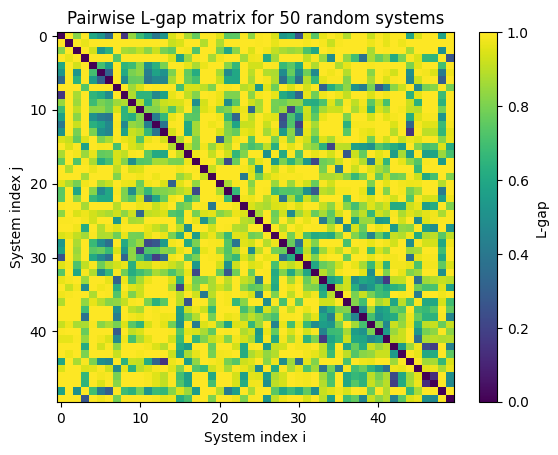

In [13]:
D_l = gapMetrics.Lgap_metric_pair(num_systems, stored_hankels, m, n, L)

plt.imshow(D_l, interpolation="nearest", aspect="auto")
plt.colorbar(label="L-gap")
plt.title("Pairwise L-gap matrix for 50 random systems")
plt.xlabel("System index i")
plt.ylabel("System index j")
plt.savefig("heatmapL_50random_systems.png",dpi=300)
plt.show()

In [14]:
def Gap_margin_from_K(K, C, y, H_system, L):
    K_prep = K @ np.linalg.pinv(C)     # shape (m, p), rough abserver
    #test if y is just random
    # y = np.random.randn(*y.shape)  # shape (T, p)
    T, p = y.shape
    y = np.random.randn(T, 1)  # shape (T, p)
    # print("K value:", K_prep)
    # print("y1:", y[1])

    # Alternate for SISO
    # K_prep = K_prep[0]
    # u_ctrl = np.array([(K_prep * y[i]).ravel() for i in range(y.shape[0])])
    u_ctrl = np.array([(K_prep.T @ y[i]).ravel() for i in range(y.shape[0])])
    # u_ctrl1 = np.array([(np.array([17,10]) @ y[i]).ravel() for i in range(y.shape[0])])
    # u_ctrl1 = u
    # u_ctrl = np.array([(K_prep.T @ u_ctrl1[i]).ravel() for i in range(y.shape[0])])
    #check data
    # print("y[1]:", (K_prep @ y[1].reshape(-1, 1)).ravel())
    # print("u_ctrl[1]:", u_ctrl[1])

    H_y_L = gapMetrics.hankel_matrix(y, L)
    # H_y_L = gapMetrics.hankel_matrix(u_ctrl1, L)
    H_u_L = gapMetrics.hankel_matrix(u_ctrl, L)

    H_C_prep = np.vstack([H_y_L, H_u_L])   # if graph convention is [y;u]
    # print("H_C_prep shape:", H_C_prep.shape)

    gap_val, _, _, _ = gapMetrics.Lgap_metric(H_system, H_C_prep, m, n, L, use_alt_formula=False)
    margin = 1.0 - gap_val

    return {"gap_to_C": gap_val, "margin": margin}

for i in range(num_systems):
    print("System", i)
    K = LQR_wrapper(u, stored_x[i])
    # print("K:", K)
    # K = np.array([[i*1, i*1]])
    Hux = stored_hankels[i]
    # print("Hux shape:", Hux.shape)
    result = Gap_margin_from_K(K, C, stored_y[i], Hux, L)
    # print("Gap to C perp:", result["gap_to_C"])
    print("Margin:", result["margin"])

# K = LQR_wrapper(u, stored_x[1])
# Hux = stored_hankels[1]
# # result = Gap_margin_from_K(K, C, stored_x[1], Hux, L)
# result = Gap_margin_from_K(K, C, stored_y[1], Hux, L)
# # result = Gap_margin_from_K(K, C, u, Hux, L)
# print("Gap to C perp:", result["gap_to_C"])
# print("Margin:", result["margin"])

System 0
Margin: 0.003035237092001708
System 1
Margin: 0.0006731180252901314
System 2
Margin: 0.0020111016145554217
System 3
Margin: 0.1318904742855781
System 4
Margin: 2.6879892485176526e-06
System 5
Margin: 8.151391544386488e-05
System 6
Margin: 0.002642486112945708
System 7
Margin: 0.4243343197853068
System 8
Margin: 0.0002852238476038771
System 9
Margin: 0.19161741136507415
System 10
Margin: 0.223971731902463
System 11
Margin: 0.0023986533840633095
System 12
Margin: 0.000637357900993063
System 13
Margin: 0.0004372078700980442
System 14
Margin: 0.015623105480810362
System 15
Margin: 0.601182894440037
System 16
Margin: 0.00030719908987231204
System 17
Margin: 0.4434491883810977
System 18
Margin: 2.694193902452735e-05
System 19
Margin: 5.4652056769022295e-08
System 20
Margin: 0.0011707039531561048
System 21
Margin: 0.1068350607493912
System 22
Margin: 0.0014290478570135878
System 23
Margin: 0.003464947154642628
System 24
Margin: 0.6972127483976684
System 25
Margin: 0.1894183707549758


In [15]:
def performance_degradation(delta, D12, u):
    # #Find the gap to C
    # delta = Gap_margin_from_K(K, C, y, Hux, L)["gap_to_C"]
    #D12 is the gap between leader and follower
    # e = np.linalg.norm(np.array([2,2]))
    e = np.linalg.norm(np.ones(10)) #this is hard coded, pls change according to other parts
    step1 = np.sqrt(2 - (delta+D12)**2)
    # step1 = 1
    step2 = np.sqrt(1 - delta**2)
    step3 = np.sqrt(1 - (delta+D12)**2)
    bound = D12 * e * step1 / (step2 * step3)
    step4 = 1/step2 + 1/step3
    bound = bound * step4
    return bound

# def performance_degradation(D12, A, B, K, init=np.array([2,2]), goal=np.array([0,0]), N=50):
#     x = init.copy()
#     traj = np.zeros((N+1, len(x)))
#     traj[0] = x
#     for t in range(N):
#         u = -K @ (x - goal)  # control input based on distance to leader
#         x = A @ x + B @ u  # state update (assuming A=I, B=I for simplicity)
#         traj[t+1] = x
#     normw = np.linalg.norm(traj)
#     # print("Trajectory norm:", normw)
#     # print("Trajectory:", traj)
#     #assume W = 1
#     bound = (2*D12 + D12**2) * normw
#     return bound

In [16]:
#best working method so far
def farthest_seeds(D, m, mode="min"):
    """
    pick m plants far apart.
    mode:
      - "avg": next seed maximizes average distance to existing plants
      - "min": next seed maximizes minimum distance to existing plants
    """
    N = D.shape[0]
    if m > N:
        raise ValueError("m cannot exceed number of plants")

    # First two: farthest pair
    i0, j0 = np.unravel_index(np.argmax(D), D.shape)
    seeds = [int(i0), int(j0)]

    while len(seeds) < m:
        candidates = [i for i in range(N) if i not in seeds]
        if mode == "avg":
            scores = [float(np.mean(D[i, seeds])) for i in candidates]
        elif mode == "min":
            scores = [float(np.min(D[i, seeds])) for i in candidates]
        else:
            raise ValueError("mode must be 'avg' or 'min'")
        seeds.append(int(candidates[int(np.argmax(scores))]))

    return seeds


def assign_by_smallest_group_average(D, seeds, order="hard_first"):
    """
    Incrementally assign remaining points.
    Each point is assigned to the group that yields smallest average distance to current members.
    """
    N = D.shape[0]
    groups = {s: [s] for s in seeds}  # key=seed id, value=list of members

    remaining = [i for i in range(N) if i not in seeds]

    if order == "hard_first":
        # points farthest from the seed set get assigned first
        seed_arr = np.array(seeds, dtype=int)
        d_to_seedset = np.min(D[:, seed_arr], axis=1)
        remaining.sort(key=lambda i: -d_to_seedset[i])
    elif order == "index":
        pass
    else:
        raise ValueError("order must be 'hard_first' or 'index'")

    for i in remaining:
        best_seed = None
        best_cost = np.inf
        for s, members in groups.items():
            cost = float(np.mean(D[i, members]))  # average distance to group members
            if cost < best_cost:
                best_cost = cost
                best_seed = s
        groups[best_seed].append(int(i))

    return groups  # dict(seed -> members)


def medoid_of_group(D, members):
    """
    Helper: choose leader as medoid (min sum distance within group).
    """
    members = np.array(members, dtype=int)
    subD = D[np.ix_(members, members)]
    k = int(np.argmin(subD.sum(axis=1)))
    return int(members[k])


def build_groups_and_check_thresholds(D, groups_dict):
    """
    Find leader, compute threshold, verify all within threshold.
    threshold_fn(members, leader) -> eps
      If None, eps is treated as +inf (no check).
    try_repair_leader:
      If True, and chosen medoid fails, try any member as leader that passes the threshold.
    """
    out = []
    well_pose = 1
    for seed, members in groups_dict.items():
        leader = medoid_of_group(D, members)
         
        K = LQR_wrapper(u, stored_x[leader])
        # print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", stored_x[leader])
        # eps = data_to_bpc(u, stored_x[leader], K)
        eps = Gap_margin_from_K(K, C, stored_x[leader], stored_hankels[leader], L)["margin"]
        # print("Threshold for leader", leader, ":", eps)
        dists = D[np.array(members, dtype=int), leader]

        ok = np.all(dists <= eps + 1e-12)

        # if (not ok) and try_repair_leader and threshold_fn is not None:
        #     # try to find any member that makes the group feasible
        #     repaired = False
        #     for cand in members:
        #         eps_c = float(threshold_fn(members, cand))
        #         if np.all(D[np.array(members, dtype=int), cand] <= eps_c + 1e-12):
        #             leader = int(cand)
        #             eps = eps_c
        #             repaired = True
        #             break
        #     ok = repaired

        if not ok:
            # provide a helpful error message
            # worst = float(np.max(dists))
            # raise ValueError(
            #     f"Threshold violation for group seeded by {seed}: "
            #     f"leader={leader}, eps={eps:.4g}, worst_dist={worst:.4g}, size={len(members)}"
            # )
            well_pose = 0

        out.append({"seed": int(seed), "leader": int(leader), "eps": float(eps), "members": [int(x) for x in members]})

    return out, well_pose


# ----- Full pipeline -----

def cluster_farthest_assign_medoid_threshold(D, m, seed_mode="min",
                                            assign_order="hard_first"):
    """
    Implements 3 steps:
      1) farthest m plants
      2) one-by-one assignment to smallest average distance group
      3) leader = medoid, check all within leader threshold
    """
    seeds = farthest_seeds(D, m, mode=seed_mode)
    groups_dict = assign_by_smallest_group_average(D, seeds, order=assign_order)
    groups = build_groups_and_check_thresholds(D, groups_dict)
    return groups


In [156]:
#grouping automatically
# groups, well_pose = cluster_farthest_assign_medoid_threshold(D_l, 5)
# print("well_pose:", well_pose)
for m in range(1, num_systems+1):
    # print(f"Trying m={m} clusters...")
    groups, well_pose = cluster_farthest_assign_medoid_threshold(D_l, m, seed_mode="avg", assign_order="hard_first")
    if well_pose == 1:
        print(f"Successfully clustered with m={m} clusters.")
        break
for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
# print("groups:", groups)
# groups = [{"leader": c, "members": [...]}, ...]

N = D_l.shape[0]
leader_of = np.full(N, -1, dtype=int)
dist_to_leader = np.zeros(N)

for g in groups:
    leader = g["leader"]
    for i in g["members"]:
        leader_of[i] = leader
        dist_to_leader[i] = D_l[leader, i]

Successfully clustered with m=16 clusters.
leader: 27 size: 1 members: [27]
leader: 44 size: 1 members: [44]
leader: 11 size: 2 members: [11, 20]
leader: 0 size: 1 members: [0]
leader: 22 size: 1 members: [22]
leader: 42 size: 1 members: [42]
leader: 6 size: 1 members: [6]
leader: 9 size: 1 members: [9]
leader: 10 size: 3 members: [38, 31, 10]
leader: 25 size: 1 members: [25]
leader: 41 size: 3 members: [15, 48, 41]
leader: 24 size: 2 members: [24, 26]
leader: 36 size: 1 members: [36]
leader: 45 size: 3 members: [40, 2, 45]
leader: 16 size: 1 members: [16]
leader: 17 size: 27 members: [3, 32, 43, 4, 29, 30, 34, 39, 18, 21, 47, 49, 12, 17, 37, 23, 46, 7, 13, 1, 35, 19, 33, 8, 5, 28, 14]


In [ ]:
# import csv

with open("cluster_assignments.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    # header
    writer.writerow(["index", "leader", "dist_to_leader"])
    
    for i in range(N):
        writer.writerow([i, leader_of[i], dist_to_leader[i]])

C:\Users\Z PL\AppData\Local\Temp\ipykernel_17192\1538616608.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
C:\Users\Z PL\AppData\Local\Temp\ipykernel_17192\1538616608.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


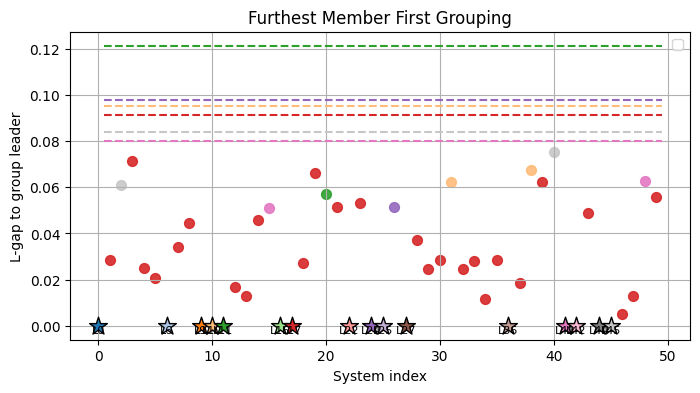

In [157]:
#plot scattered plot for auto clustering
plt.figure(figsize=(8, 4))

unique_leaders = sorted(set(leader_of))
colors = plt.cm.tab20(range(len(unique_leaders)))
leader_color = {l: colors[k] for k, l in enumerate(unique_leaders)}

for i in range(N):
    l = leader_of[i]
    if i == l:
        # leader: star marker
        plt.scatter(
            i,
            dist_to_leader[i],
            marker="*",
            s=180,
            color=leader_color[l],
            edgecolor="k",
            zorder=3,
        )
        plt.text(i, 0, f"L{l}", ha="center", va="top", fontsize=8)
    else:
        plt.scatter(
            i,
            dist_to_leader[i],
            color=leader_color[l],
            s=50,
            alpha=0.9,
        )

for g in groups:
    leader = g["leader"]
    members = g["members"]
    eps = g["eps"]
    if len(members) > 1:
        plt.hlines(
            eps,
            xmin= 0.5,
            xmax= N - 0.5,
            colors=leader_color[leader],
            linestyles="--", 
            # label=f"Threshold for group {leader}"
        )

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.xlabel("System index")
plt.ylabel("L-gap to group leader")
plt.title("Furthest Member First Grouping")
plt.grid(True)
plt.legend()
plt.show()


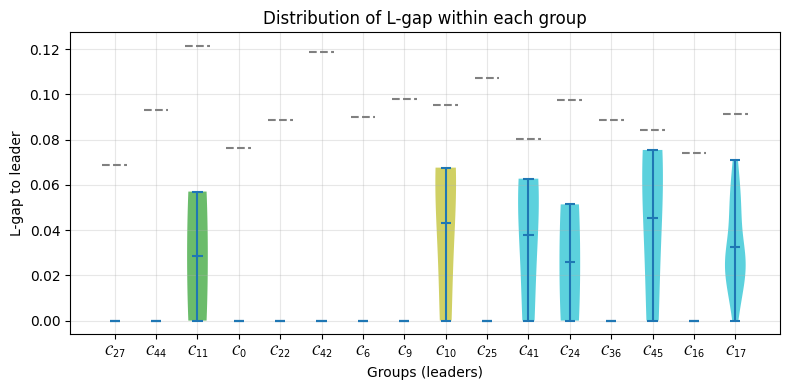

In [152]:
#violin plot for distribution of distances to leader within each group
group_data = []
labels = []

for g in groups:
    leader = g["leader"]
    members = g["members"]
    
    values = [dist_to_leader[i] for i in members]
    
    group_data.append(values)
    labels.append(fr"$\mathcal{{C}}_{{{leader}}}$")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data, showmeans=True, showmedians=False)

# color each violin
unique_leaders = [g["leader"] for g in groups]
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# # optional: color mean lines
# for part in ("cbars", "cmins", "cmaxes", "cmeans"):
#     if part in vp:
#         vp[part].set_color("black")

#plot threshold lines for each group
for i, g in enumerate(groups, start=1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Groups (leaders)")
plt.ylabel("L-gap to leader")
plt.title("Distribution of L-gap within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [177]:
def control_effectiveness(A, B, K, init=np.array([2,2]), goal=np.array([0,0]), N=50):
    """
    N is the number of steps to simulate.
    This is for performance degradation
    """
    x = init.copy()
    # x = np.array([0,0])
    total_error = 0.0
    Q = np.eye(2)
    R = np.eye(1)*0.1 #TODO: can adapt to n change
    N = 20
    for _ in range(N):
        # u = -K @ (x + 1 - goal) #For step d=1
        u = -K @ (x - goal)
        x = A @ x + B @ u
        # total_error += np.linalg.norm(x - goal) + np.linalg.norm(u)
        # total_error += np.linalg.norm(x - goal)
        e = x - goal
        total_error += e.T @ Q @ e + u.T @ R @ u
        # print(f"x: {x}, u: {u}, error: {total_error}")
        # print("e part:", e.T @ Q @ e, " u part:", u.T @ R @ u)
    return total_error

def control_effectiveness2(A, B, K, init=np.array([2,2]), goal=np.array([0,0]), N=10):
    """
    N is the number of steps to simulate.
    Also this is for performance difference
    """
    # x = init.copy()
    x = np.array([0,0])
    total_error = 0.0
    Q = np.eye(2)
    R = np.eye(1) #TODO: can adapt to n change
    for _ in range(N):
        u = -K @ (x + 1 - goal) #For step d=1
        # u = -K @ (x - goal)
        x = A @ x + B @ u
        # total_error += np.linalg.norm(x - goal) + np.linalg.norm(u)
        # total_error += np.linalg.norm(x - goal)
        e = x - goal
        total_error += e.T @ Q @ e + u.T @ R @ u
        # print(f"x: {x}, u: {u}, error: {total_error}")
        # print("e part:", e.T @ Q @ e, " u part:", u.T @ R @ u)
    return total_error

leader: 27 size: 1 members: [27]
leader: 44 size: 1 members: [44]
leader: 11 size: 2 members: [11, 20]
leader: 0 size: 1 members: [0]
leader: 22 size: 1 members: [22]
leader: 42 size: 1 members: [42]
leader: 6 size: 1 members: [6]
leader: 9 size: 1 members: [9]
leader: 10 size: 3 members: [38, 31, 10]
leader: 25 size: 1 members: [25]
leader: 41 size: 3 members: [15, 48, 41]
leader: 24 size: 2 members: [24, 26]
leader: 36 size: 1 members: [36]
leader: 45 size: 3 members: [40, 2, 45]
leader: 16 size: 1 members: [16]
leader: 17 size: 27 members: [3, 32, 43, 4, 29, 30, 34, 39, 18, 21, 47, 49, 12, 17, 37, 23, 46, 7, 13, 1, 35, 19, 33, 8, 5, 28, 14]


Text(0.5, 1.0, "Error under Leader's Controller")

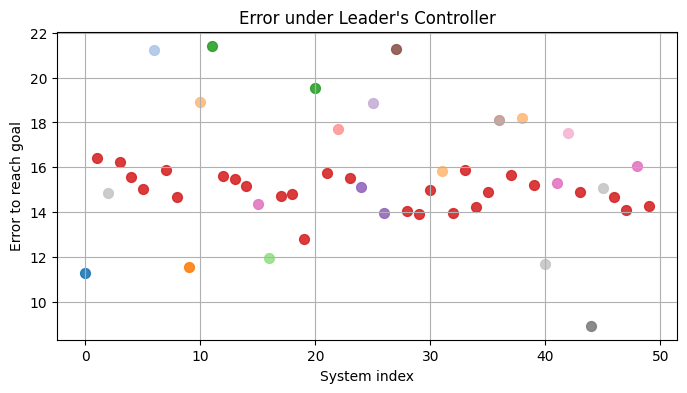

In [172]:
#proof of controllability (new)
error = {}

for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    # A_cl_leader = A_leader - B_leader @ K_leader
    # eigs_leader = np.linalg.eigvals(A_cl_leader)
    # print(f"Leader system {g['leader']} eigs: {eigs_leader}")
    leader_error = control_effectiveness(A_leader, B_leader, K_leader)
    error[g["leader"]] = leader_error
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness(A, B, K_leader)
        error[m] = member_error

#plot errors
plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
        label=f"Group led by {leader}"
    )
plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error to reach goal")
plt.title("Error under Leader's Controller")   

leader: 27 size: 1 members: [27]
leader: 44 size: 1 members: [44]
leader: 11 size: 2 members: [11, 20]
leader: 0 size: 1 members: [0]
leader: 22 size: 1 members: [22]
leader: 42 size: 1 members: [42]
leader: 6 size: 1 members: [6]
leader: 9 size: 1 members: [9]
leader: 10 size: 3 members: [38, 31, 10]
leader: 25 size: 1 members: [25]
leader: 41 size: 3 members: [15, 48, 41]
leader: 24 size: 2 members: [24, 26]
leader: 36 size: 1 members: [36]
leader: 45 size: 3 members: [40, 2, 45]
leader: 16 size: 1 members: [16]
leader: 17 size: 27 members: [3, 32, 43, 4, 29, 30, 34, 39, 18, 21, 47, 49, 12, 17, 37, 23, 46, 7, 13, 1, 35, 19, 33, 8, 5, 28, 14]


Text(0.5, 1.0, 'Performance Difference')

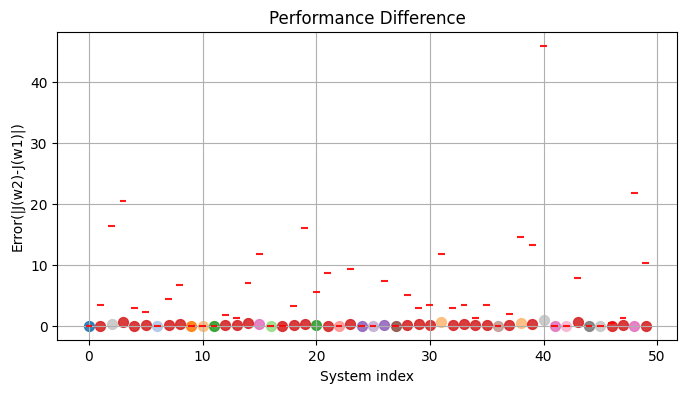

In [173]:
error_individual = {}
bound_individual = {}

for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    leader_error = control_effectiveness2(A_leader, B_leader, K_leader)
    error_individual[g["leader"]] = 0.0
    bound_individual[g["leader"]] = 0.0
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness2(A, B, K_leader)
        error_individual[m] = abs(member_error - leader_error)
        bound = performance_degradation((1-g["eps"]), D_l[g["leader"], m], u)
        # print(f"Dist to C: {g["eps"]}, dist to leader: {D_l[g['leader'], m]}")
        # bound = performance_degradation(D_l[g["leader"], m], stored_A[m], stored_B[m], K_leader)
        # print(f"System {m} error: {error_individual[m]}, bound: {bound}")
        bound_individual[m] = bound
#plot errors
plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error_individual[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
        label=f"Group led by {leader}"
    )
    for m in members:
        plt.hlines(
            y=bound_individual[m],
            xmin=m - 0.3,
            xmax=m + 0.3,
            colors="red",
            alpha=0.9,
            # label=f"Group led by {leader}"
        )
        if bound_individual[m] < error_individual[m]:
            print(f"Bound violation for system {m} in group led by {leader}: error={error_individual[m]:.4f}, bound={bound_individual[m]:.4f}")

plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error(|J(w2)-J(w1)|)")
plt.title("Performance Difference")   

In [174]:
with open("performance_difference_plot_data.csv", "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "method",
        "group_id",
        "leader",
        "member",
        "member_error_diff",
        "bound",
        "bound_violated",
    ])

    for group_id, g in enumerate(groups):
        leader = g["leader"]
        eps = g["eps"]

        K_leader = LQR_wrapper(u, stored_x[leader])
        A_leader = stored_A[leader]
        B_leader = stored_B[leader]
        leader_error = control_effectiveness2(A_leader, B_leader, K_leader)

        # leader row
        writer.writerow([
            "groups",
            group_id,
            leader,
            leader,
            0.0,
            0.0,
            False,
        ])

        # member rows
        for m in g["members"]:
            error_value = error_individual[m]
            bound_value = bound_individual[m]
            violated = bound_value < error_value

            writer.writerow([
                "groups",
                group_id,
                leader,
                m,
                error_value,
                bound_value,
                violated
            ])

C:\Users\Z PL\AppData\Local\Temp\ipykernel_17192\2481570110.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


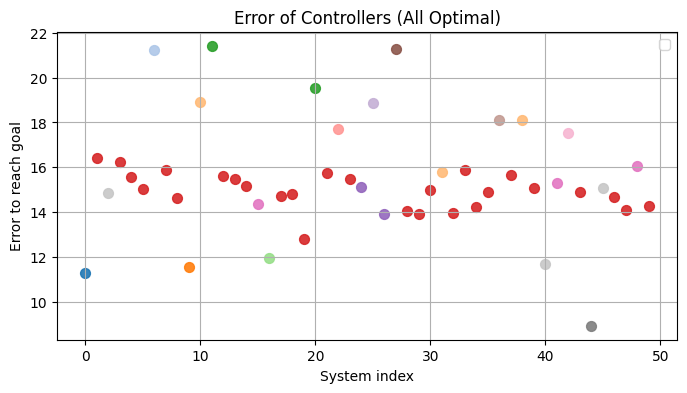

In [175]:
#All optimal example
error_optimal = {}
for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    error_o = control_effectiveness(A, B, K)
    error_optimal[i] = error_o

plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [error_optimal[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
    )
plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Error to reach goal")
plt.title("Error of Controllers (All Optimal)")
plt.legend()

Text(0.5, 1.0, 'Performance Degradation Compared to Optimal')

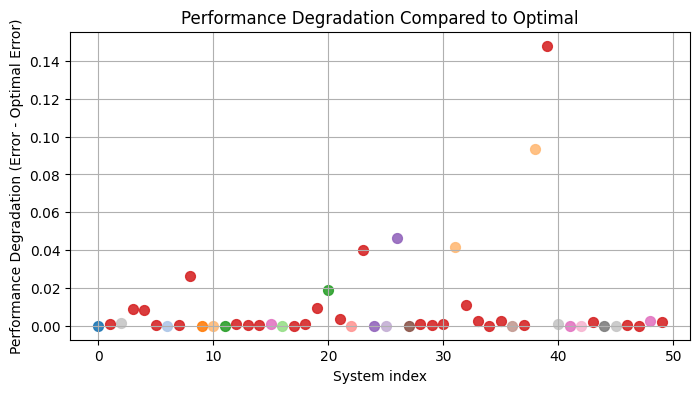

In [176]:
delta_error = {i: error[i] - error_optimal[i] for i in range(num_systems)}

#plot errors
plt.figure(figsize=(8, 4))
for g in groups:
    leader = g["leader"]
    members = g["members"]
    plt.scatter(
        members,
        [delta_error[m] for m in members],
        color=leader_color[leader],
        s=50,
        alpha=0.9,
        label=f"Group led by {leader}"
    )
plt.grid(True)
plt.xlabel("System index")
plt.ylabel("Performance Degradation (Error - Optimal Error)")
plt.title("Performance Degradation Compared to Optimal")

In [ ]:
# import csv
# print(error)
with open("cluster_control_error.csv", "w", newline="") as f:
    writer = csv.writer(f)
    # header
    writer.writerow(["index", "leader", "error", "error_optimal", "delta_error"])
    for i in range(N):
        writer.writerow([i, leader_of[i], error[i], error_optimal[i], delta_error[i]])

gap_between_sys1_sys2: 0.9831870490436163
w shape: (50, 2)


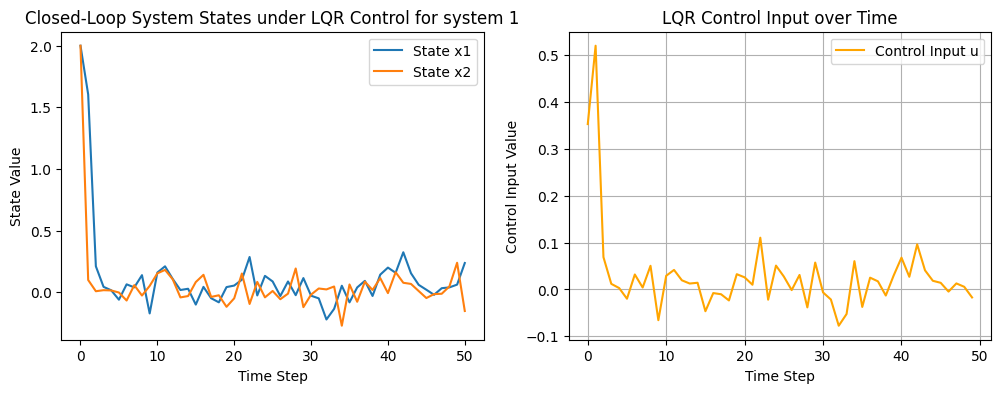

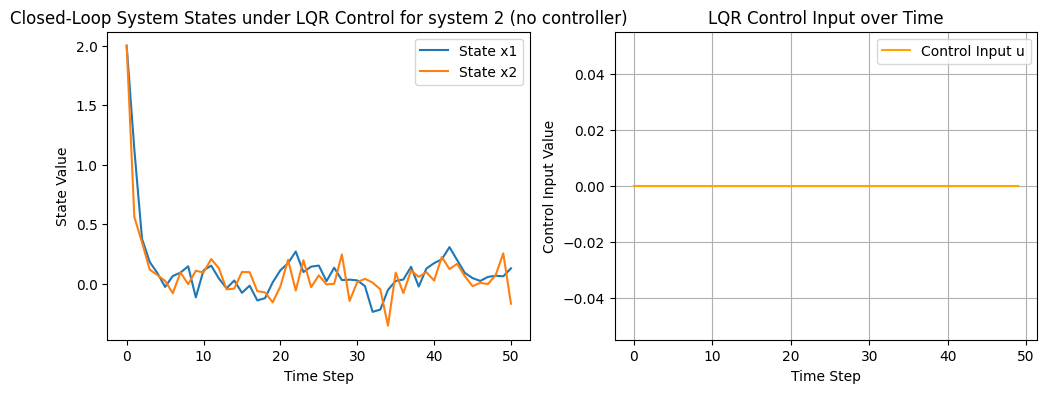

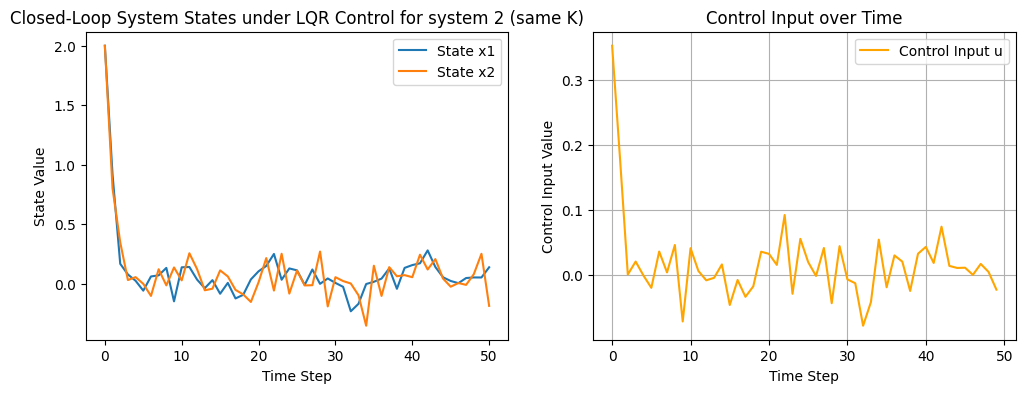

In [28]:
#proof of controllability (old)

#test whether the same controller can be used for 2 systems
#LQR controller
Q = np.eye(2)
# Q[1,1] = 0 #get rid of x2 penalty
R = np.eye(1)*0.1
T_d = 20  #data length for LQR
sys1_index = 3
sys2_index = 25
print("gap_between_sys1_sys2:", D_l[sys1_index, sys2_index])

U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
X0 = stored_x[sys1_index][0:T_d, :].T # shape (n, T)  == X_{0,T}
X1 = stored_x[sys1_index][1:T_d+1, :].T # shape (n, T)  == X_{1,T}

# simulate closed loop system. Assumed using system 1 where A is a 2x2 matrix
N = 50 #number of control steps
#disturbance
w = np.random.randn(N, 2).reshape(-1, 2) * 0.1
print("w shape:", w.shape)

x0 = np.array([[2],[2]]) #initial state
x_cl = np.zeros((N+1, x0.shape[0], x0.shape[1]))
x_cl[0, :, :] = x0 #initial state
xf = np.array([[0],[0]]) #desired state
u_cl = np.zeros((N, R.shape[0], 1))
K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
# K_control = np.array([[2, 1]])  #test with wrong controller
# bias = np.array([[2.0], [2.0]])
bias = np.zeros((2,1))
# bias = 2

for k in range(N):
    u_control = -K_control @ (x_cl[k] + bias - xf) 
    # if k == 1:
    #     bias = np.array([[0.0], [0.0]])
        # bias = 0
    # u_control = np.zeros((1, 1))
    #add disturbance
    x_cl[k+1] = stored_A[sys1_index] @ x_cl[k] + stored_B[sys1_index] @ u_control + w[k].reshape(-1, 1)
    # print("stored_A[0]:", stored_A[0], "stored_B[0]:", stored_B[0])
    # x_cl[k+1] += w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 1')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#system 2
for k in range(N):
    # u_control = -K_control @ (x_cl[k] - xf)
    u_control = np.zeros((1, 1))
    x_cl[k+1] = stored_A[sys2_index] @ x_cl[k] + stored_B[sys2_index] @ u_control + w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (no controller)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#use same controller on system 2
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[sys2_index] @ x_cl[k] + stored_B[sys2_index] @ u_control + w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#For one groups' trajectories
# ----- choose one group only -----
g = groups[0]                 # or any specific group
leader = g["leader"]
members = g["members"]

# ----- LQR settings -----
Q = np.eye(2)
R = np.eye(1) * 0.1
T_d = 20
N = 50

x0 = np.array([[2.0], [2.0]])
xf = np.array([[0.0], [0.0]])

# ----- compute K only from the leader -----
U0 = u[0:T_d].T
X0 = stored_x[leader][0:T_d, :].T
X1 = stored_x[leader][1:T_d+1, :].T

K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
print("Leader:", leader)
print("K_control shape:", K_control.shape)
print("K_control:\n", K_control)
print("number of members in group:", len(members))

# ----- simulate all members with the same K -----
traj_dict = {}
u_dict = {}

for idx in members:
    # optional: same disturbance for all plants
    w = np.random.randn(N, 2) * 0.1

    x_cl = np.zeros((N + 1, x0.shape[0], x0.shape[1]))
    u_cl = np.zeros((N, R.shape[0], 1))
    x_cl[0] = x0

    A = stored_A[idx]
    B = stored_B[idx]

    for k in range(N):
        u_control = -K_control @ (x_cl[k] - xf)
        x_cl[k + 1] = A @ x_cl[k] + B @ u_control + w[k].reshape(-1, 1)
        u_cl[k] = u_control

    traj_dict[idx] = x_cl
    u_dict[idx] = u_cl

# ----- plot all state trajectories in one figure -----
t = np.arange(N + 1)

plt.figure(figsize=(8, 5))

# collect all x1 trajectories
x1_all = []

for idx in members:
    x_cl = traj_dict[idx]
    x1 = x_cl[:, 0, 0]
    x1_all.append(x1)

    if idx == leader:
        plt.plot(t, x1, linewidth=3, label=f"leader {idx}")
        plt.scatter(t[0], x1[0], s=60, marker="o")
        plt.scatter(t[-1], x1[-1], s=80, marker="*")
    else:
        plt.plot(t, x1, alpha=0.5, linewidth=1.5)

x1_all = np.array(x1_all)          # shape: (num_members, N+1)
lower = np.min(x1_all, axis=0)     # lower envelope
upper = np.max(x1_all, axis=0)     # upper envelope

plt.fill_between(t, lower, upper, alpha=0.2, label="envelope")

plt.xlabel("time step")
plt.ylabel("x1 state value(output)")
plt.title("Closed-loop state trajectories using leader's K")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# import csv

# put leader first, then the remaining members
ordered_members = [leader] + [idx for idx in members if idx != leader]

with open("group_trajectories.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # header
    header = ["t", f"y1({leader})"]
    for k, idx in enumerate(ordered_members[1:], start=2):
        header.append(f"y{k}({idx})")
    writer.writerow(header)

    # rows
    for t in range(N + 1):
        row = [t]

        for idx in ordered_members:
            # first state component x_1
            y = traj_dict[idx][t, 0, 0]
            row.append(y)

        writer.writerow(row)

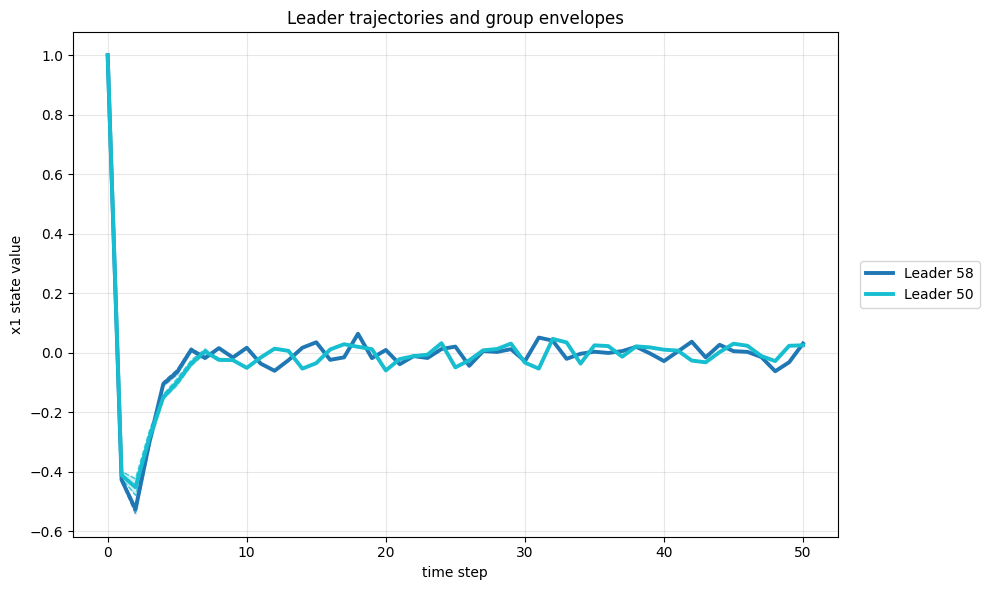

In [99]:
#For plotting all trajectories in clusters
# ----- settings -----
Q = np.eye(2)
R = np.eye(1)
T_d = 20
N = 50

x0 = np.array([[1.0], [1.0]])
xf = np.array([[0.0], [0.0]])

# choose which state/output to plot
state_idx = 0   # 0 -> x1, 1 -> x2

t = np.arange(N + 1)

# store results for plotting + CSV
group_plot_data = []

# colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

# ----- simulate each group using its own leader controller -----
for group_id, g in enumerate(groups):
    leader = g["leader"]
    members = g["members"]

    # compute K from leader data
    U0 = u[0:T_d].T
    X0 = stored_x[leader][0:T_d, :].T
    X1 = stored_x[leader][1:T_d+1, :].T

    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)

    traj_dict = {}
    u_dict = {}
    w = np.random.randn(N, 2) * 0.05  # same disturbance for all members in the group

    for idx in members:
        # different disturbance for each system
        # w = np.random.randn(N, 2) * 0.05

        x_cl = np.zeros((N + 1, x0.shape[0], x0.shape[1]))
        u_cl = np.zeros((N, R.shape[0], 1))
        x_cl[0] = x0

        A = stored_A[idx]
        B = stored_B[idx]

        for k in range(N):
            u_control = -K_control @ (x_cl[k] - xf)
            x_cl[k + 1] = A @ x_cl[k] + B @ u_control + w[k].reshape(-1, 1) * 0.5
            u_cl[k] = u_control

        traj_dict[idx] = x_cl
        u_dict[idx] = u_cl

    # collect the selected state for all members
    y_all = []
    for idx in members:
        y = traj_dict[idx][:, state_idx, 0]
        y_all.append(y)

    y_all = np.array(y_all)
    env_low = np.min(y_all, axis=0)
    env_high = np.max(y_all, axis=0)
    leader_y = traj_dict[leader][:, state_idx, 0]

    group_plot_data.append({
        "leader": leader,
        "members": members,
        "traj_dict": traj_dict,
        "u_dict": u_dict,
        "leader_y": leader_y,
        "env_low": env_low,
        "env_high": env_high,
        "color": colors[group_id],
    })

# ----- plot -----
plt.figure(figsize=(10, 6))

for data in group_plot_data:
    leader = data["leader"]
    members = data["members"]
    traj_dict = data["traj_dict"]
    c = data["color"]

    # # faint member trajectories
    # for idx in members:
    #     y = traj_dict[idx][:, state_idx, 0]
    #     if idx != leader:
    #         plt.plot(t, y, color=c, alpha=0.20, linewidth=1.2, zorder=1)

    # envelope
    plt.fill_between(
        t,
        data["env_low"],
        data["env_high"],
        color=c,
        alpha=0.20,
        zorder=2
    )

    # envelope boundaries
    plt.plot(t, data["env_low"], "--", color=c, linewidth=1.0, alpha=0.8, zorder=3)
    plt.plot(t, data["env_high"], "--", color=c, linewidth=1.0, alpha=0.8, zorder=3)

    # leader
    plt.plot(
        t,
        data["leader_y"],
        color=c,
        linewidth=2.8,
        label=f"Leader {leader}",
        zorder=4
    )

plt.xlabel("time step")
plt.ylabel(f"x{state_idx+1} state value")
plt.title("Leader trajectories and group envelopes")
plt.grid(True, alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.show()

# ----- CSV export -----
# csv_filename = "group_leader_envelopes.csv"

# with open(csv_filename, "w", newline="") as f:
#     writer = csv.writer(f)

#     # header
#     header = ["t"]
#     for data in group_plot_data:
#         leader = data["leader"]
#         header.extend([
#             f"leader_{leader}",
#             f"env_low_{leader}",
#             f"env_high_{leader}",
#         ])
#     writer.writerow(header)

#     # rows
#     for k in range(N + 1):
#         row = [t[k]]
#         for data in group_plot_data:
#             row.extend([
#                 data["leader_y"][k],
#                 data["env_low"][k],
#                 data["env_high"][k],
#             ])
#         writer.writerow(row)

# print(f"CSV written to {csv_filename}")

well_pose: 1


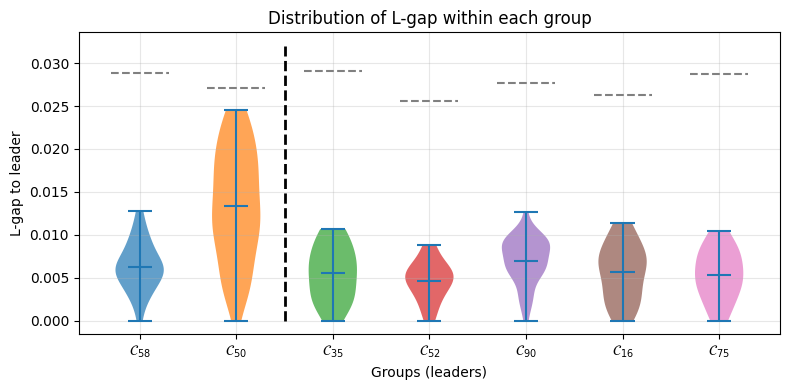

In [20]:
#grouping with specified m number of clusters
groupsm, well_posem = cluster_farthest_assign_medoid_threshold(D_l, 5)
print("well_pose:", well_posem)

N = D_l.shape[0]
leader_ofm = np.full(N, -1, dtype=int)
dist_to_leaderm = np.zeros(N)

for g in groupsm:
    leader = g["leader"]
    for i in g["members"]:
        leader_ofm[i] = leader
        dist_to_leaderm[i] = D_l[leader, i]

#violin plot for distribution of distances to leader within each group
# group_datam = []
# labelsm = []

for g in groupsm:
    leader = g["leader"]
    members = g["members"]
    
    values = [dist_to_leaderm[i] for i in members]
    
    group_data.append(values)
    labels.append(fr"$\mathcal{{C}}_{{{leader}}}$")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data, showmeans=True, showmedians=False)

# color each violin
# unique_leaders = []
for g in groupsm:
    unique_leaders.append(g["leader"])
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# # optional: color mean lines
# for part in ("cbars", "cmins", "cmaxes", "cmeans"):
#     if part in vp:
#         vp[part].set_color("black")

#plot threshold lines for each group
for i, g in enumerate(groups, start=1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

plt.vlines(
    len(groups) + 0.5,
    ymin=0,
    ymax=max(g["eps"] for g in groupsm) * 1.1,
    colors="black",
    linestyles="--",
    linewidth=2.0,
    # label="Furthest Member First Thresholds"
)

for i, g in enumerate(groupsm, start=len(groups)+1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Groups (leaders)")
plt.ylabel("L-gap to leader")
plt.title("Distribution of L-gap within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
#CSV for violin of both methods; clustering and eps

with open("group_violin_data.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    # header
    writer.writerow([
        "method",           # "groups" or "groupsm"
        "group_id",
        "leader",
        "member",
        "distance_to_leader",
        "threshold_eps"
    ])
    
    # --- original groups ---
    for group_id, g in enumerate(groups):
        leader = g["leader"]
        eps = g["eps"]
        
        for i in g["members"]:
            writer.writerow([
                "groups",
                group_id,
                leader,
                i,
                D_l[leader, i],
                eps
            ])
    
    # --- new groupsm ---
    for group_id, g in enumerate(groupsm):
        leader = g["leader"]
        eps = g["eps"]
        
        for i in g["members"]:
            writer.writerow([
                "groupsm",
                group_id,
                leader,
                i,
                dist_to_leaderm[i],
                eps
            ])

leader: 35 size: 15 members: [12, 23, 94, 80, 14, 87, 35, 60, 72, 37, 70, 78, 31, 51, 18]
leader: 52 size: 18 members: [93, 57, 85, 76, 6, 39, 2, 32, 8, 67, 73, 11, 52, 47, 10, 95, 82, 34]
leader: 90 size: 35 members: [74, 83, 45, 89, 81, 38, 29, 64, 66, 46, 42, 62, 49, 50, 56, 77, 33, 5, 54, 24, 3, 27, 55, 63, 90, 7, 25, 92, 59, 88, 99, 20, 19, 15, 17]
leader: 16 size: 18 members: [44, 69, 91, 61, 40, 48, 98, 1, 86, 96, 26, 16, 13, 71, 43, 4, 30, 9]
leader: 75 size: 14 members: [22, 36, 41, 79, 68, 84, 97, 53, 0, 28, 58, 75, 21, 65]


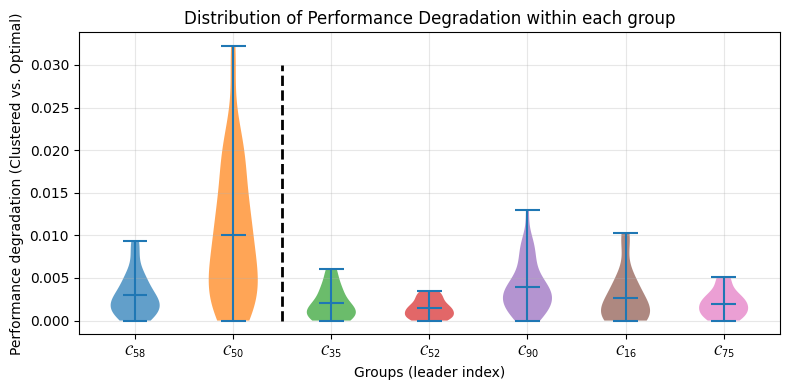

In [25]:
#proof of controllability (for adding 5)
    
errorm = {}

for g in groupsm:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    # A_cl_leader = A_leader - B_leader @ K_leader
    # eigs_leader = np.linalg.eigvals(A_cl_leader)
    # print(f"Leader system {g['leader']} eigs: {eigs_leader}")
    leader_error = control_effectiveness(A_leader, B_leader, K_leader)
    errorm[g["leader"]] = leader_error
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness(A, B, K_leader)
        errorm[m] = member_error

error_optimalm = {}
for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    error_o = control_effectiveness(A, B, K)
    error_optimalm[i] = error_o

delta_errorm = {i: errorm[i] - error_optimalm[i] for i in range(num_systems)}

#violin plot
# group_data_error = []
# labels_error = []

for g in groupsm:
    leader = g["leader"]
    members = g["members"]
    
    values = [delta_errorm[i] for i in members]
    
    group_data_error.append(values)
    labels_error.append(fr"$\mathcal{{C}}_{{{leader}}}$")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data_error, showmeans=True, showmedians=False)

# color each violin
unique_leadersm = [g["leader"] for g in groupsm]
colors = plt.cm.tab10(range(len(unique_leadersm)+len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.vlines(
    len(groups) + 0.5,
    ymin=0.0,
    ymax=0.03,
    colors="black",
    linestyles="--",
    linewidth=2.0,
    label="Furthest Member First Thresholds"
)

plt.xticks(range(1, len(labels_error) + 1), labels_error)
plt.xlabel("Groups (leader index)")
plt.ylabel("Performance degradation (Clustered vs. Optimal)")
plt.title("Distribution of Performance Degradation within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
with open("performance_degradation_violin.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    writer.writerow([
        "method",          # "groups" or "groupsm"
        "group_id",
        "leader",
        "member",
        "delta_error",     # errorm - optimal
        "leader_error",    # error using leader K
        "optimal_error"    # error using own K
    ])
    
    # --- groups (old clustering) ---
    for group_id, g in enumerate(groups):
        leader = g["leader"]
        
        for i in g["members"]:
            writer.writerow([
                "groups",
                group_id,
                leader,
                i,
                delta_error[i],
                error[i],
                error_optimal[i]
            ])
    
    # --- groupsm (new clustering) ---
    for group_id, g in enumerate(groupsm):
        leader = g["leader"]
        
        for i in g["members"]:
            writer.writerow([
                "groupsm",
                group_id,
                leader,
                i,
                delta_errorm[i],
                errorm[i],
                error_optimalm[i]
            ])

In [ ]:
# ----- simulate each group using its own leader controller -----
for group_id, g in enumerate(groupsm):
    leader = g["leader"]
    members = g["members"]

    # compute K from leader data
    U0 = u[0:T_d].T
    X0 = stored_x[leader][0:T_d, :].T
    X1 = stored_x[leader][1:T_d+1, :].T

    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)

    traj_dict = {}
    u_dict = {}
    w = np.random.randn(N, 2) * 0.05  # same disturbance for all members in the group

    for idx in members:
        # different disturbance for each system
        # w = np.random.randn(N, 2) * 0.05

        x_cl = np.zeros((N + 1, x0.shape[0], x0.shape[1]))
        u_cl = np.zeros((N, R.shape[0], 1))
        x_cl[0] = x0

        A = stored_A[idx]
        B = stored_B[idx]

        for k in range(N):
            u_control = -K_control @ (x_cl[k] - xf)
            x_cl[k + 1] = A @ x_cl[k] + B @ u_control + w[k].reshape(-1, 1) * 0.5
            u_cl[k] = u_control

        traj_dict[idx] = x_cl
        u_dict[idx] = u_cl

    # collect the selected state for all members
    y_all = []
    for idx in members:
        y = traj_dict[idx][:, state_idx, 0]
        y_all.append(y)

    y_all = np.array(y_all)
    env_low = np.min(y_all, axis=0)
    env_high = np.max(y_all, axis=0)
    leader_y = traj_dict[leader][:, state_idx, 0]

    group_plot_data.append({
        "leader": leader,
        "members": members,
        "traj_dict": traj_dict,
        "u_dict": u_dict,
        "leader_y": leader_y,
        "env_low": env_low,
        "env_high": env_high,
    })

# ----- plot -----
plt.figure(figsize=(10, 6))

for data in group_plot_data:
    leader = data["leader"]
    members = data["members"]
    traj_dict = data["traj_dict"]
    c = data["color"]

    # # faint member trajectories
    # for idx in members:
    #     y = traj_dict[idx][:, state_idx, 0]
    #     if idx != leader:
    #         plt.plot(t, y, color=c, alpha=0.20, linewidth=1.2, zorder=1)

    # envelope
    plt.fill_between(
        t,
        data["env_low"],
        data["env_high"],
        color=c,
        alpha=0.20,
        zorder=2
    )

    # envelope boundaries
    plt.plot(t, data["env_low"], "--", color=c, linewidth=1.0, alpha=0.8, zorder=3)
    plt.plot(t, data["env_high"], "--", color=c, linewidth=1.0, alpha=0.8, zorder=3)

    # leader
    plt.plot(
        t,
        data["leader_y"],
        color=c,
        linewidth=2.8,
        label=f"Leader {leader}",
        zorder=4
    )

plt.xlabel("time step")
plt.ylabel(f"x{state_idx+1} state value")
plt.title("Leader trajectories and group envelopes")
plt.grid(True, alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.show()

Leader 35 dist to C: 0.9709128830743362, max dist to leader: 0.010664663520053755
Leader 52 dist to C: 0.9743501723521509, max dist to leader: 0.008770700811816978
Leader 90 dist to C: 0.9723600806033617, max dist to leader: 0.012643137275635975
Leader 16 dist to C: 0.973684250625015, max dist to leader: 0.011396020658297918
Leader 75 dist to C: 0.9712977156658236, max dist to leader: 0.010394672939624976


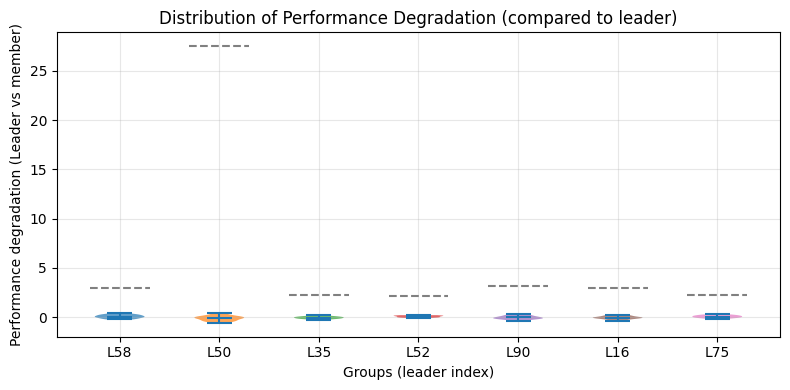

In [133]:
#for comparing with leader's trajectory
bound_error = {i: error[i] - error[leader_of[i]] for i in range(num_systems)}
bound_errorm = {i: errorm[i] - errorm[leader_ofm[i]] for i in range(num_systems)}

#violin plot
group_data_error_to_leader = []
labels_error_to_leader = []
performance_degradation_bound = []

for g in groups:
    leader = g["leader"]
    members = g["members"]
    max_dist = max(dist_to_leader[i] for i in members)
    dist_leader_C = Gap_margin_from_K(LQR_wrapper(u, stored_x[leader]), C, stored_x[leader], stored_hankels[leader], L)["gap_to_C"]
    performance_degradation_bound.append(performance_degradation(dist_leader_C, max_dist, u))
    values = [bound_error[i] for i in members]
    
    group_data_error_to_leader.append(values)
    labels_error_to_leader.append(f"L{leader}")

for g in groupsm:
    leader = g["leader"]
    members = g["members"]
    max_distm = max(dist_to_leaderm[i] for i in members)
    dist_leader_Cm = Gap_margin_from_K(LQR_wrapper(u, stored_x[leader]), C, stored_x[leader], stored_hankels[leader], L)["gap_to_C"]
    print(f"Leader {leader} dist to C: {dist_leader_Cm}, max dist to leader: {max_distm}")
    performance_degradation_bound.append(performance_degradation(dist_leader_Cm, max_distm, u))
    values = [bound_errorm[i] for i in members]
    
    group_data_error_to_leader.append(values)
    labels_error_to_leader.append(f"L{leader}")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data_error_to_leader, showmeans=True, showmedians=False)

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

for i in range(len(performance_degradation_bound)):
    plt.hlines(
        performance_degradation_bound[i],
        xmin=i + 1 - 0.3,
        xmax=i + 1 + 0.3,
        colors="grey",
        linestyles="--",
        linewidth=1.5,
        # label="Theoretical Performance Degradation Bound" if i == 0 else None
    )

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels_error_to_leader) + 1), labels_error_to_leader)
plt.xlabel("Groups (leader index)")
plt.ylabel("Performance degradation (Leader vs member)")
plt.title("Distribution of Performance Degradation (compared to leader)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
print("Performance degradation bound for each group:", performance_degradation_bound[0])

Performance degradation bound for each group: 0.3679432724953734
